In [1]:
import pathlib
from argparse import ArgumentParser
import yaml
import torch
import src.spatial_attn_lightning as attn_tracking_lightning


In [2]:
### Get most recent config
config_path = "config/binaural_attn/word_task_half_co_loc_v08_gender_bal_4M_w_no_cue_learned.yaml"
ckpt_path = "attn_cue_models/word_task_half_co_loc_v08_gender_bal_4M_w_no_cue_learned_no_constraints/checkpoints/epoch=3-step=47662.ckpt"
config = yaml.load(open(config_path, 'r'), Loader=yaml.FullLoader)


In [3]:
model = attn_tracking_lightning.BinauralAttentionModule.load_from_checkpoint(checkpoint_path=ckpt_path, config=config, strict=True)
model = model.eval()

Using explicit dim specification for demeaning in audio transforms
Using BinauralAuditoryAttentionCNN
v08 True
num_classes={'num_words': 800}
Model performing word task
Conv block order: LN -> Conv -> ReLU
coch_affine: True


/om2/user/imgriff/conda_envs/pytorch_2/lib/python3.11/site-packages/torchaudio/functional/functional.py:1371: UserWarning: "kaiser_window" resampling method name is being deprecated and replaced by "sinc_interp_kaiser" in the next release. The default behavior remains unchanged.
  warnings.warn(


center_crop=True
binaural=True
Binaural cochleagram
using FIR cochleagram


In [4]:
attn_modules = model.attn_modules

In [5]:
list(attn_modules[0].named_parameters())

[('bias',
  Parameter containing:
  tensor([-0.1626], device='cuda:0', requires_grad=True)),
 ('slope',
  Parameter containing:
  tensor([1.1478], device='cuda:0', requires_grad=True)),
 ('threshold',
  Parameter containing:
  tensor([0.0284], device='cuda:0', requires_grad=True))]

In [6]:
attn_params = {}
for param in model.named_parameters():
    if 'attn' in param[0]:
        layer, parameter = param[0].split('.')[3:]
        if layer not in attn_params:
            attn_params[layer] = {}
        attn_params[layer][parameter] = param[1].item()


In [7]:
n_attn_blocks = len(attn_params)

In [8]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

## Plot attentional filters

In [9]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

In [10]:
n_attn_blocks

8

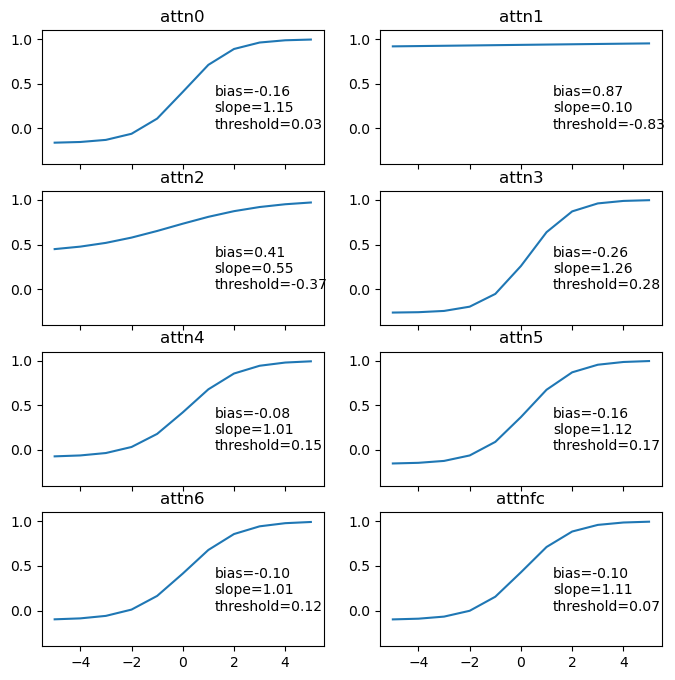

In [12]:
fig, axs = plt.subplots(n_attn_blocks//2, 2, sharex=True, figsize=(8,8))
axs = axs.ravel()
layer_names = list(attn_params.keys())
# layer_names = ['cochleagram'] + layer_names

x = np.arange(-5,6)

for i, layer in enumerate(attn_params.keys()):
    bias = attn_params[layer]['bias']
    slope = attn_params[layer]['slope']
    threshold = attn_params[layer]['threshold']

    axs[i].plot(x, bias + (1-bias) * sigmoid((x - threshold) * slope))
    axs[i].text(1.25, 0., f"bias={bias:.2f}\nslope={slope:.2f}\nthreshold={threshold:.2f}")
    axs[i].set_title(layer_names[i])
    # axs[i].set_ylim(-0.1,1.1)
    axs[i].set_ylim(-0.4,1.1)

    
    
# plt.tight_layout()

# Look at cue-free arch with auxilary input

In [13]:
### Get most recent config
config_path = "config/binaural_attn/word_task_half_co_loc_v08_gender_bal_4M_w_no_cue.yaml"
ckpt_path = "attn_cue_models/word_task_half_co_loc_v08_gender_bal_4M_w_no_cue_no_constraints/checkpoints/epoch=1-step=12277-v7.ckpt"
config = yaml.load(open(config_path, 'r'), Loader=yaml.FullLoader)


In [14]:
model = attn_tracking_lightning.BinauralAttentionModule.load_from_checkpoint(checkpoint_path=ckpt_path, config=config, strict=True)
model = model.eval()
attn_params = {}
for param in model.named_parameters():
    if 'attn' in param[0]:
        layer, parameter = param[0].split('.')[3:]
        if layer not in attn_params:
            attn_params[layer] = {}
        attn_params[layer][parameter] = param[1].item()


Using explicit dim specification for demeaning in audio transforms
Using BinauralAuditoryAttentionCNN
v08 True
num_classes={'num_words': 800}
Model performing word task
Conv block order: LN -> Conv -> ReLU
coch_affine: True


/om2/user/imgriff/conda_envs/pytorch_2/lib/python3.11/site-packages/torchaudio/functional/functional.py:1371: UserWarning: "kaiser_window" resampling method name is being deprecated and replaced by "sinc_interp_kaiser" in the next release. The default behavior remains unchanged.
  warnings.warn(


center_crop=True
binaural=True
Binaural cochleagram
using FIR cochleagram


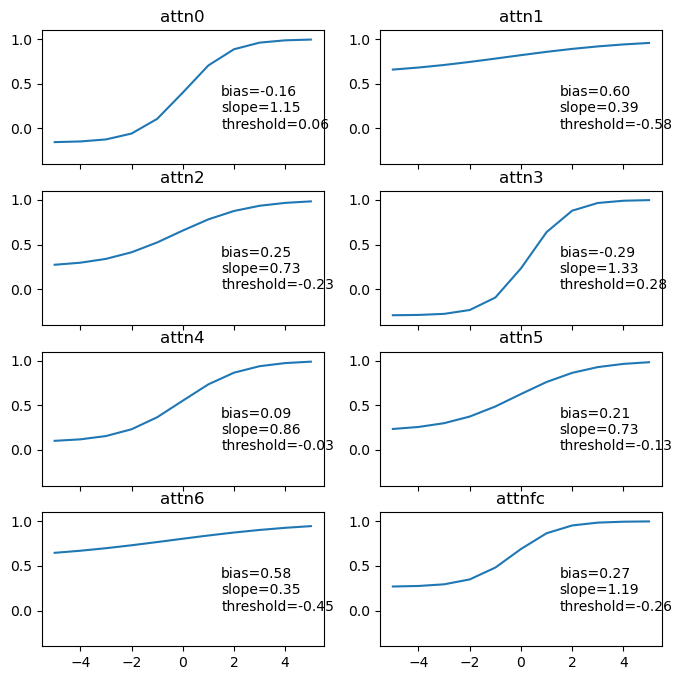

In [16]:
fig, axs = plt.subplots(n_attn_blocks//2, 2, sharex=True, figsize=(8,8))
axs = axs.ravel()
layer_names = list(attn_params.keys())
# layer_names = ['cochleagram'] + layer_names

x = np.arange(-5,6)

for i, layer in enumerate(attn_params.keys()):
    bias = attn_params[layer]['bias']
    slope = attn_params[layer]['slope']
    threshold = attn_params[layer]['threshold']

    axs[i].plot(x, bias + (1-bias) * sigmoid((x - threshold) * slope))
    axs[i].text(1.5, 0., f"bias={bias:.2f}\nslope={slope:.2f}\nthreshold={threshold:.2f}")
    axs[i].set_title(layer_names[i])
    # axs[i].set_ylim(-0.1,1.1)
    axs[i].set_ylim(-0.4,1.1)

    
    
# plt.tight_layout()

# Look at best performing model

In [17]:
### Get most recent config
config_path = "config/binaural_attn/word_task_half_co_loc_v08_gender_bal_4M_sanity.yaml"
ckpt_path = "attn_cue_models/word_task_half_co_loc_v08_gender_bal_4M_sanity/checkpoints/epoch=7-step=89878.ckpt"
config = yaml.load(open(config_path, 'r'), Loader=yaml.FullLoader)


In [18]:
model = attn_tracking_lightning.BinauralAttentionModule.load_from_checkpoint(checkpoint_path=ckpt_path, config=config, strict=True)
model = model.eval()
attn_params = {}
for param in model.named_parameters():
    if 'attn' in param[0]:
        layer, parameter = param[0].split('.')[3:]
        if layer not in attn_params:
            attn_params[layer] = {}
        attn_params[layer][parameter] = param[1].item()


Using explicit dim specification for demeaning in audio transforms
Using BinauralAuditoryAttentionCNN
v08 True
num_classes={'num_words': 800}
Model performing word task
Conv block order: LN -> Conv -> ReLU
coch_affine: True
center_crop=True
binaural=True
Binaural cochleagram
using FIR cochleagram


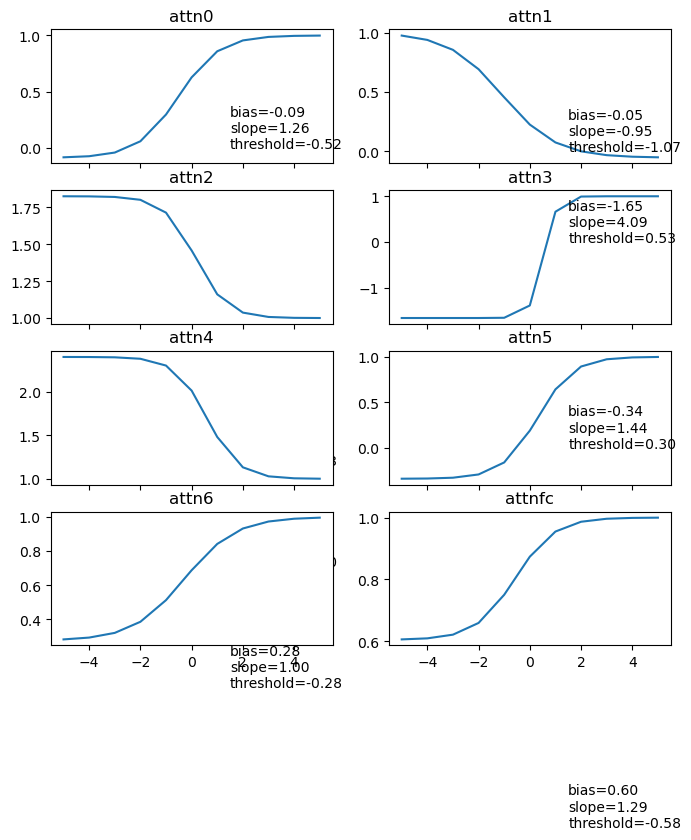

In [19]:
fig, axs = plt.subplots(n_attn_blocks//2, 2, sharex=True, figsize=(8,8))
axs = axs.ravel()
layer_names = list(attn_params.keys())
# layer_names = ['cochleagram'] + layer_names

x = np.arange(-5,6)

for i, layer in enumerate(attn_params.keys()):
    bias = attn_params[layer]['bias']
    slope = attn_params[layer]['slope']
    threshold = attn_params[layer]['threshold']

    axs[i].plot(x, bias + (1-bias) * sigmoid((x - threshold) * slope))
    axs[i].text(1.5, 0., f"bias={bias:.2f}\nslope={slope:.2f}\nthreshold={threshold:.2f}")
    axs[i].set_title(layer_names[i])
    # axs[i].set_ylim(-0.1,1.1)
    # axs[i].set_ylim(-0.4,1.1)

    
    
# plt.tight_layout()